In [2]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import shap

conn = sqlite3.connect("../egg_analysis.db")
df = pd.read_sql("SELECT * FROM master_table", conn)
df['year_month'] = pd.to_datetime(df['year_month'])

print(df.shape)
print(df.head())

(117, 12)
  year_month  egg_price  feed_ppi  electricity_ppi  egg_ppi  egg_cpi  \
0 2016-04-01       5259     94.82            98.81    89.81   86.773   
1 2016-05-01       5216     94.82            98.81    85.53   84.645   
2 2016-06-01       5260     94.82            98.81    87.35   84.451   
3 2016-07-01       5272     94.82            98.81    95.35   84.665   
4 2016-08-01       5332     94.82           100.00    97.00   85.258   

   feed_lag1  feed_lag2  feed_lag3  elec_lag1  elec_lag2  elec_lag3  
0      94.82      95.69      95.69      98.81      98.81      98.81  
1      94.82      94.82      95.69      98.81      98.81      98.81  
2      94.82      94.82      94.82      98.81      98.81      98.81  
3      94.82      94.82      94.82      98.81      98.81      98.81  
4      94.82      94.82      94.82      98.81      98.81      98.81  


### AI 주요 발생 시기   
- 2016.11 ~ 2017.04 (1차 대란)   
- 2020.11 ~ 2021.04 (2차 대란)   

In [15]:
df['ai_dummy'] = 0
df.loc[
    (df['year_month'] >= '2016-11-01') &
    (df['year_month'] <= '2017-04-01'), 'ai_dummy'] = 1
df.loc[
    (df['year_month'] >= '2020-11-01') &
    (df['year_month'] <= '2021-04-01'), 'ai_dummy'] = 1
print(df['ai_dummy'].value_counts())

train = df[df['year_month'] < '2024-01-01']
test  = df[df['year_month'] >= '2024-01-01']

print("train:", train.shape)  
print("test :", test.shape)  

features = [
    'feed_ppi', 'electricity_ppi',
    'feed_lag1', 'feed_lag2', 'feed_lag3',
    'elec_lag1', 'elec_lag2', 'elec_lag3'
]

features_with_dummy = [
    'feed_ppi', 'electricity_ppi',
    'feed_lag1', 'feed_lag2', 'feed_lag3',
    'elec_lag1', 'elec_lag2', 'elec_lag3',
    'ai_dummy'
]

X_train = train[features]
y_train = train['egg_price']
X_test  = test[features]
y_test  = test['egg_price']

X_train_d = train[features_with_dummy]
X_test_d  = test[features_with_dummy]

ai_dummy
0    105
1     12
Name: count, dtype: int64
train: (93, 13)
test : (24, 13)


In [16]:
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

model_ols = sm.OLS(y_train, X_train_sm).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              egg_price   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     2.438
Date:                Thu, 07 May 2026   Prob (F-statistic):             0.0202
Time:                        16:42:50   Log-Likelihood:                -764.11
No. Observations:                  93   AIC:                             1546.
Df Residuals:                      84   BIC:                             1569.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            3516.9772    964.041     

In [17]:
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

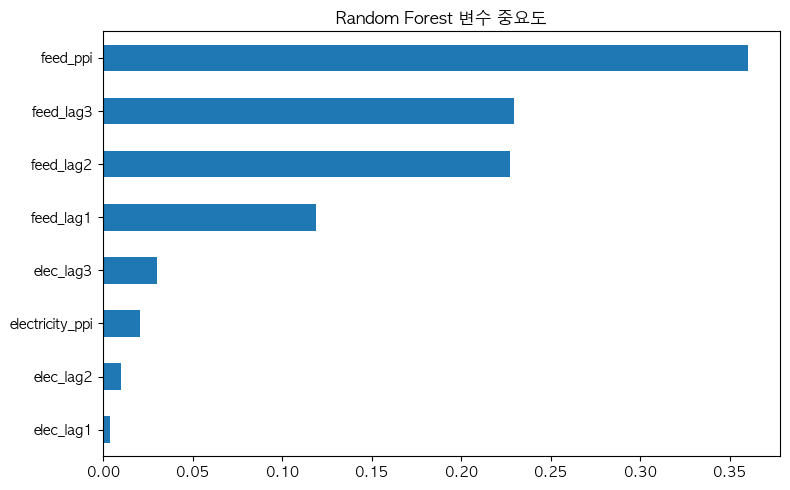

In [7]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Random Forest 변수 중요도')
plt.tight_layout()
plt.savefig('../output/figures/rf_importance.png', dpi=150)
plt.show()

In [18]:
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [19]:
results = {}

# OLS
pred_ols = model_ols.predict(X_test_sm)
results['OLS'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_ols)),
    'MAE' : mean_absolute_error(y_test, pred_ols)
}

# Random Forest
pred_rf = rf.predict(X_test)
results['RF'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf)),
    'MAE' : mean_absolute_error(y_test, pred_rf)
}

# XGBoost
pred_xgb = xgb.predict(X_test)
results['XGB'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_xgb)),
    'MAE' : mean_absolute_error(y_test, pred_xgb)
}

# 비교 출력
for name, result in results.items():
    print(f"{name} → RMSE: {result['RMSE']:.0f}원, MAE: {result['MAE']:.0f}원")

OLS → RMSE: 286원, MAE: 226원
RF → RMSE: 274원, MAE: 229원
XGB → RMSE: 344원, MAE: 281원


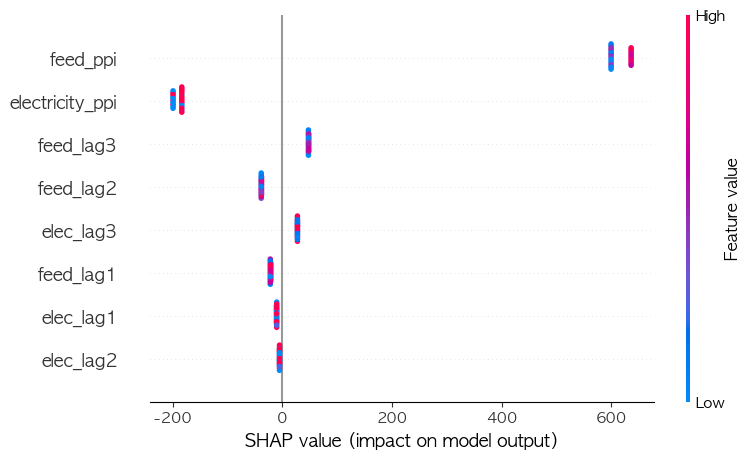

In [20]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test,
                  feature_names=features,
                  show=False)
plt.savefig('../output/figures/shap_summary.png', dpi=150)
plt.show()

## H3 가설 검증 - AI(조류 독감) 발생 시기 더미변수   

EDA에서 2017년, 2021년 계란값 급등이   
원가 외 외부 충격(AI 발생)에 의한 것으로 확인됨   

AI 발생 시기를 더미변수로 추가했을 때   
모델 성능이 향상되는지 확인하여 H3 가설 검증   

In [26]:
# RF + AI 더미변수
rf_d = RandomForestRegressor(n_estimators=100, random_state=42)
rf_d.fit(X_train_d, y_train)

pred_rf_d = rf_d.predict(X_test_d)
rmse_d = np.sqrt(mean_squared_error(y_test, pred_rf_d))
mae_d  = mean_absolute_error(y_test, pred_rf_d)

print(f"RF (원가만)       → RMSE: 274원, MAE: 229원")
print(f"RF (원가+AI더미)  → RMSE: {rmse_d:.0f}원, MAE: {mae_d:.0f}원")

RF (원가만)       → RMSE: 274원, MAE: 229원
RF (원가+AI더미)  → RMSE: 273원, MAE: 228원
